# Task 1 — ML Basics: Student Performance Prediction

Predict a student's final exam score from study hours, attendance, previous scores, sleep, and other factors. This notebook covers data generation, preprocessing, model training, and evaluation.

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
RNG = np.random.default_rng(42)

DATA_DIR = Path("../data"); IMG_DIR = Path("../images"); OUT_DIR = Path("../outputs")
for d in (DATA_DIR, IMG_DIR, OUT_DIR): d.mkdir(exist_ok=True)


## 2. Load the dataset
The dataset was generated with realistic relationships between features and final score (see `pipeline.py` for generation code). Here we simply load it.

In [3]:
df = pd.read_csv(DATA_DIR / "student_performance.csv")
df.head()


,study_hours,attendance_percent,previous_scores,sleep_hours,extracurricular,parental_education,internet_access,final_score
0,5.11,71.9,64.2,6.22,No,Bachelors,Yes,69.1
1,2.42,69.0,82.0,8.07,No,Bachelors,Yes,63.0
2,6.00,86.1,84.0,7.17,No,Bachelors,Yes,70.7
3,6.38,86.6,43.7,5.89,Yes,High School,Yes,67.9
4,0.60,97.4,60.3,5.67,Yes,Bachelors,Yes,65.5


In [4]:
df.describe()

,study_hours,attendance_percent,previous_scores,sleep_hours,final_score
count,800.000000,780.000000,800.000000,780.000000,800.000000
mean,4.376812,81.248205,64.064125,6.844218,66.207125
std,2.014828,11.648882,14.939034,1.291876,9.806443
min,0.000000,40.000000,20.000000,3.080000,37.000000
25%,2.925000,73.775000,54.175000,5.940000,59.600000
50%,4.435000,81.950000,65.150000,6.810000,66.000000
75%,5.690000,89.400000,74.100000,7.762500,73.125000
max,10.330000,100.000000,100.000000,10.000000,96.800000


In [5]:
df.isna().sum()

study_hours            0
attendance_percent    20
previous_scores        0
sleep_hours           20
extracurricular        0
parental_education     0
internet_access        0
final_score            0
dtype: int64

## 3. Preprocessing
Fill missing numeric values with the median, encode categorical columns, then scale features.

In [6]:
df_clean = df.copy()
df_clean["attendance_percent"] = df_clean["attendance_percent"].fillna(df_clean["attendance_percent"].median())
df_clean["sleep_hours"] = df_clean["sleep_hours"].fillna(df_clean["sleep_hours"].median())

label_encoders = {}
for col in ["extracurricular", "parental_education", "internet_access"]:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

feature_cols = ["study_hours", "attendance_percent", "previous_scores",
                "sleep_hours", "extracurricular", "parental_education", "internet_access"]
X = df_clean[feature_cols]
y = df_clean["final_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape


((640, 7), (160, 7))

## 4. Exploratory Data Analysis

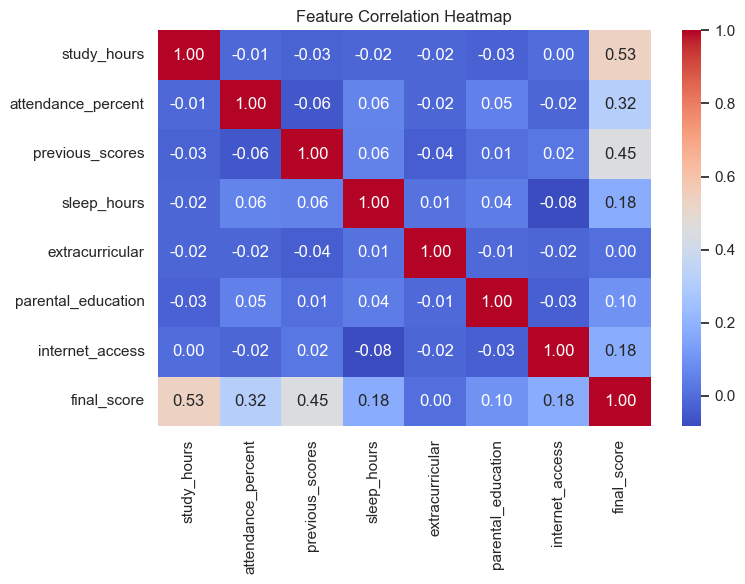

In [7]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean[feature_cols + ["final_score"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(IMG_DIR / "correlation_heatmap.png", dpi=120)
plt.show()


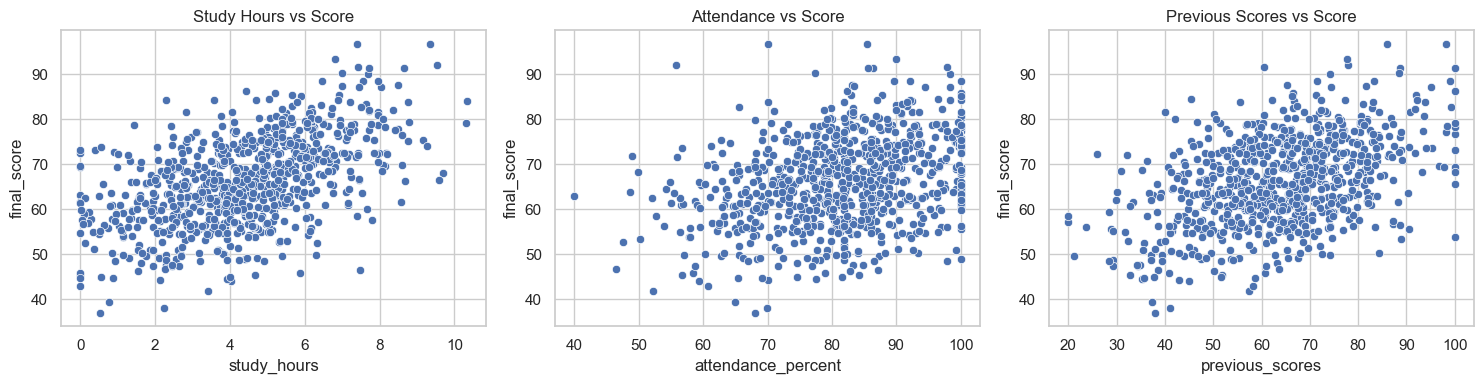

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.scatterplot(x="study_hours", y="final_score", data=df_clean, ax=axes[0]); axes[0].set_title("Study Hours vs Score")
sns.scatterplot(x="attendance_percent", y="final_score", data=df_clean, ax=axes[1]); axes[1].set_title("Attendance vs Score")
sns.scatterplot(x="previous_scores", y="final_score", data=df_clean, ax=axes[2]); axes[2].set_title("Previous Scores vs Score")
plt.tight_layout()
plt.savefig(IMG_DIR / "scatter_relationships.png", dpi=120)
plt.show()


## 5. Train models
We compare a Linear Regression baseline against a Decision Tree and a Random Forest.

In [9]:
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    }

pd.DataFrame(results).T


,MAE,RMSE,R2
LinearRegression,4.521217,5.438803,0.706214
DecisionTree,5.945298,7.396629,0.456634
RandomForest,5.222922,6.318625,0.603476


## 6. Evaluate the best model

Best model: LinearRegression {'MAE': 4.5212174116813095, 'RMSE': np.float64(5.438803212371986), 'R2': 0.7062139465980161}


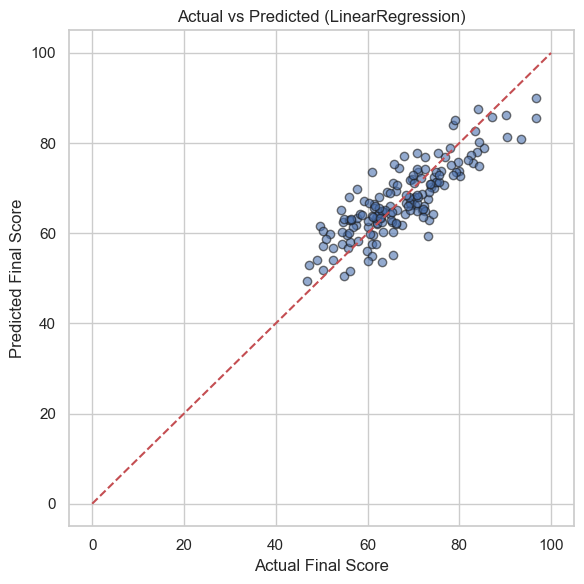

In [10]:
best_model_name = max(results, key=lambda k: results[k]["R2"])
best_model = models[best_model_name]
print("Best model:", best_model_name, results[best_model_name])

plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions[best_model_name], alpha=0.6, edgecolor="k")
plt.plot([0,100],[0,100],"r--")
plt.xlabel("Actual Final Score"); plt.ylabel("Predicted Final Score")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.tight_layout()
plt.savefig(IMG_DIR / "actual_vs_predicted.png", dpi=120)
plt.show()


## 7. Save model artifacts

In [11]:
joblib.dump(best_model, OUT_DIR / "best_model.joblib")
joblib.dump(scaler, OUT_DIR / "scaler.joblib")
with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump({"results": {k: {m: float(v) for m,v in r.items()} for k,r in results.items()},
               "best_model": best_model_name}, f, indent=2)
print("Saved.")


Saved.


## Conclusion
All three models capture the main drivers of student performance (study hours, attendance, previous scores). The best-performing model is saved to `outputs/best_model.joblib` along with the scaler for use in downstream tasks.